# Notebook 13 – Model Explainability

## What is Model Explainability?
Model explainability is the process of understanding how a machine learning model arrives at its predictions. While high accuracy is important, knowing **why** a model made a certain decision is critical for trust, safety, and regulatory compliance.

### Why Explainability?
1. **Trust:** Users are more likely to trust a model if they understand its logic.
2. **Debugging:** Helps identify if the model is relying on "spurious correlations" (shortcuts) rather than actual patterns.
3. **Fairness:** Ensures the model isn't using biased or unethical features to make decisions.
4. **Business Value:** Allows stakeholders to derive insights from the model (e.g., "Which features drive customer churn?").

### Interpretable vs Black-Box Models
- **Interpretable Models:** Models that are simple enough for a human to understand by looking at them.
  - *Examples:* Linear Regression (coefficients), Decision Trees (split paths), Logistic Regression.
- **Black-Box Models:** Complex models where the internal logic is too intricate for humans to trace.
  - *Examples:* Random Forests, XGBoost, Neural Networks, SVMs.

## Feature Importance
Feature importance provides a global view of which features had the most influence on the model's predictions across the entire dataset.

- **Permutation Importance:** A model-agnostic method. It randomly shuffles a single feature's values; if the model's performance drops significantly, that feature was important.
- **Built-in Importance:** Many tree-based models (Random Forest, XGBoost) provide importance based on how much a feature reduced impurity (Gini/Entropy) across all splits.

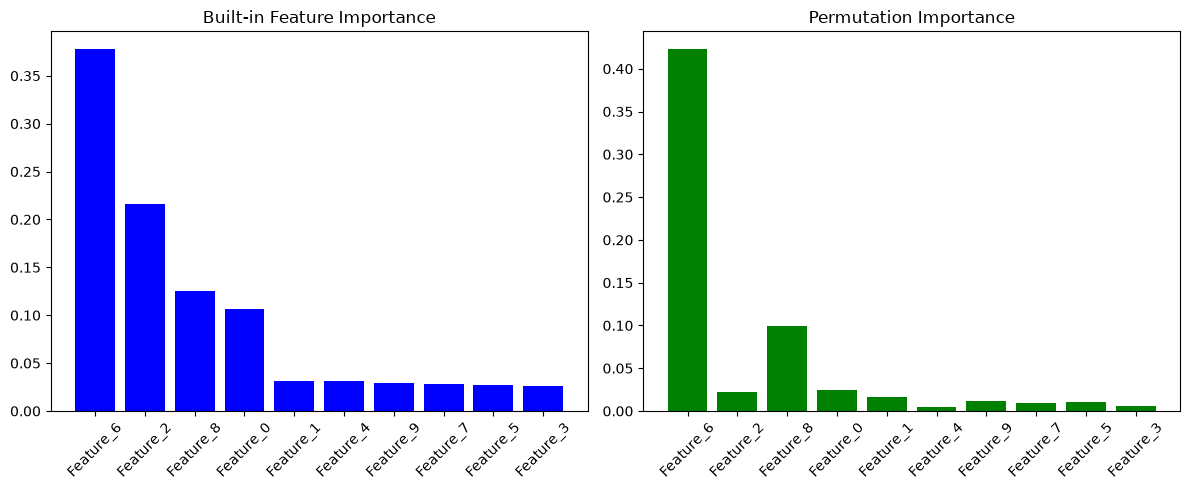

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# Create dataset
X, y = make_classification(n_samples=1000, n_features=10, random_state=42)
feature_names = [f"Feature_{i}" for i in range(10)]
X_df = pd.DataFrame(X, columns=feature_names)

# Train model
model = RandomForestClassifier(random_state=42).fit(X, y)

# 1. Built-in Feature Importance
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# 2. Permutation Importance
perm_importance = permutation_importance(model, X, y, n_repeats=10, random_state=42)

# Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Built-in Feature Importance")
plt.bar(range(10), importances[indices], color='blue')
plt.xticks(range(10), [feature_names[i] for i in indices], rotation=45)

plt.subplot(1, 2, 2)
plt.title("Permutation Importance")
plt.bar(range(10), perm_importance.importances_mean[indices], color='green')
plt.xticks(range(10), [feature_names[i] for i in indices], rotation=45)

plt.tight_layout()
plt.show()

## Advanced Explainability: SHAP & Partial Dependence

### Partial Dependence Plots (PDP)
PDPs show the marginal effect of one or two features on the predicted outcome of a machine learning model. It helps visualize whether the relationship is linear, monotonic, or more complex.

### SHAP (SHapley Additive exPlanations)
SHAP is a powerful framework based on game theory. It assigns each feature an "importance value" for **every single prediction**.

- **Global Explanation:** The average absolute SHAP values for all samples tell us which features are most important overall.
- **Local Explanation:** For a specific sample, SHAP tells us exactly how much each feature contributed to moving the prediction away from the base value (average prediction).

In [2]:
# Note: SHAP requires 'pip install shap'
# This is a conceptual implementation as shap can be slow for large datasets
try:
    import shap
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    # Summary plot for global explanation
    plt.figure()
    shap.summary_plot(shap_values, X_df, plot_type="bar")
    plt.show()
    
    # Single prediction explanation (Local)
    plt.figure()
    shap.initjs()
    # shap.force_plot(explainer.expected_value[1], shap_values[1][0,:], X_df.iloc[0,:])
    print("SHAP values computed. Use shap.summary_plot for global and shap.force_plot for local explanations.")
except ImportError:
    print("SHAP library not installed. Please run: !pip install shap")

SHAP library not installed. Please run: !pip install shap
